In [ ]:
import torch
import torchvision
from torch.utils.data import DataLoader
from torchvision.models.detection import FasterRCNN, fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.datasets import CocoDetection
from torchvision.transforms import ToTensor, functional as F
import matplotlib.pyplot as plt
import 
from PIL import Image

In [5]:
class CocoTransform:
    def __call__(self, image, target):
        image = F.to_tensor(image)
        return image, target

In [9]:
def get_coco_dataset(img_dir, ann_file):
    return CocoDetection(
        root=img_dir,
        annFile=ann_file,
        transforms=CocoTransform()
    )

# Update paths to point to the actual data location
train_dataset = get_coco_dataset(
    img_dir='output/split_data/train',
    ann_file='output/split_data/train/annotations.json'
)

# Use test split as validation
val_dataset = get_coco_dataset(
    img_dir='output/split_data/test',
    ann_file='output/split_data/test/annotations.json'
)

batch_size = 4
shuffle = True
collate_fn = lambda x: tuple(zip(*x))
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=shuffle, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


In [10]:
# Verify dataset loading
print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

# Check a sample from the dataset
sample_image, sample_target = train_dataset[0]
print(f"\nSample image shape: {sample_image.shape}")
print(f"Sample target: {sample_target}")
print(f"Number of annotations in sample: {len(sample_target)}")

# Verify categories
import json
with open('output/split_data/train/annotations.json', 'r') as f:
    coco_data = json.load(f)
    
categories = {cat['id']: cat['name'] for cat in coco_data['categories']}
print(f"\nNumber of categories: {len(categories)}")
print(f"Categories: {sorted(categories.items())}")
print(f"\nDataset is ready for training!")


Train dataset size: 2894
Validation dataset size: 1241

Sample image shape: torch.Size([3, 80, 210])
Sample target: [{'id': 1, 'image_id': 1, 'category_id': 16, 'bbox': [54, 28, 11, 34], 'area': 374, 'iscrowd': 0, 'segmentation': []}, {'id': 2, 'image_id': 1, 'category_id': 30, 'bbox': [73, 31, 11, 31], 'area': 341, 'iscrowd': 0, 'segmentation': []}, {'id': 3, 'image_id': 1, 'category_id': 13, 'bbox': [92, 38, 24, 25], 'area': 600, 'iscrowd': 0, 'segmentation': []}, {'id': 4, 'image_id': 1, 'category_id': 10, 'bbox': [123, 29, 25, 33], 'area': 825, 'iscrowd': 0, 'segmentation': []}]
Number of annotations in sample: 4

Number of categories: 36
Categories: [(1, '0'), (2, '1'), (3, '2'), (4, '3'), (5, '4'), (6, '5'), (7, '6'), (8, '7'), (9, '8'), (10, '9'), (11, 'a'), (12, 'b'), (13, 'c'), (14, 'd'), (15, 'e'), (16, 'f'), (17, 'g'), (18, 'h'), (19, 'i'), (20, 'j'), (21, 'k'), (22, 'l'), (23, 'm'), (24, 'n'), (25, 'o'), (26, 'p'), (27, 'q'), (28, 'r'), (29, 's'), (30, 't'), (31, 'u'), (32,

In [11]:
def get_model(num_classes):
    model = fasterrcnn_resnet50_fpn(pretrained=True)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

In [12]:
num_classes = 36 + 1  # 36 characters + background
model = get_model(num_classes)

/Users/wesho/repos/captcha-model/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/wesho/repos/captcha-model/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [13]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

# Hyperparameters
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)
num_epochs = 10

In [14]:
def train_one_epoch(model, optimizer, data_loader, device, epoch):
    model.train()
    total_loss = 0.0
    num_batches = 0
    
    for batch_idx, (images, targets) in enumerate(data_loader):
        images = [img.to(device) for img in images]

        processed_targets = []
        valid_images = []
        
        for i, target in enumerate(targets):
            boxes = []
            labels = []

            for obj in target:
                bbox = obj["bbox"]
                x, y, w, h = bbox

                if w > 0 and h > 0:
                    boxes.append([x, y, x + w, y + h])
                    labels.append(obj["category_id"])

            # Only process if there are valid boxes
            if boxes:
                processed_target = {
                    "boxes": torch.tensor(boxes, dtype=torch.float32).to(device),
                    "labels": torch.tensor(labels, dtype=torch.int64).to(device)
                }
                processed_targets.append(processed_target)
                valid_images.append(images[i])

        # Skip batch if no valid images
        if not processed_targets:
            continue
            
        images = valid_images

        # Zero gradients before forward pass
        optimizer.zero_grad()
        
        # Forward pass
        loss_dict = model(images, processed_targets)
        losses = sum(loss for loss in loss_dict.values())

        # Backward pass
        losses.backward()
        optimizer.step()
        
        total_loss += losses.item()
        num_batches += 1
        
        # Print progress every 50 batches
        if (batch_idx + 1) % 50 == 0:
            print(f"  Batch [{batch_idx + 1}/{len(data_loader)}], Loss: {losses.item():.4f}")
    
    avg_loss = total_loss / num_batches if num_batches > 0 else 0.0
    print(f"Epoch [{epoch + 1}], Average Loss: {avg_loss:.4f}")
    return avg_loss
    

In [15]:
num_epochs = 2

# Create outputs directory if it doesn't exist
import os
os.makedirs('outputs', exist_ok=True)

for epoch in range(num_epochs):
    print(f"\n{'='*50}")
    print(f"Training Epoch {epoch + 1}/{num_epochs}")
    print(f"{'='*50}")
    
    train_one_epoch(model, optimizer, train_loader, device, epoch)
    lr_scheduler.step()

    model_path = f"outputs/model_epoch_{epoch + 1}.pth"
    torch.save(model.state_dict(), model_path)

    print(f"Model saved to {model_path}\n")



Training Epoch 1/2
  Batch [50/724], Loss: 1.6900
  Batch [100/724], Loss: 1.1650
  Batch [150/724], Loss: 1.0745
  Batch [200/724], Loss: 0.9580
  Batch [250/724], Loss: 1.0087
  Batch [300/724], Loss: 0.9068
  Batch [350/724], Loss: 0.8198
  Batch [400/724], Loss: 0.7236
  Batch [450/724], Loss: 0.6809
  Batch [500/724], Loss: 0.6823
  Batch [550/724], Loss: 0.6522
  Batch [600/724], Loss: 0.5347
  Batch [650/724], Loss: 0.6233
  Batch [700/724], Loss: 0.4060
Epoch [1], Average Loss: 0.8741
Model saved to outputs/model_epoch_1.pth


Training Epoch 2/2
  Batch [50/724], Loss: 0.5279
  Batch [100/724], Loss: 0.5238
  Batch [150/724], Loss: 0.3107
  Batch [200/724], Loss: 0.5511
  Batch [250/724], Loss: 0.4094
  Batch [300/724], Loss: 0.4484
  Batch [350/724], Loss: 0.2873
  Batch [400/724], Loss: 0.3407
  Batch [450/724], Loss: 0.3721
  Batch [500/724], Loss: 0.3665
  Batch [550/724], Loss: 0.3584
  Batch [600/724], Loss: 0.3332
  Batch [650/724], Loss: 0.3053
  Batch [700/724], Loss:

/Users/wesho/repos/captcha-model/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/wesho/repos/captcha-model/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


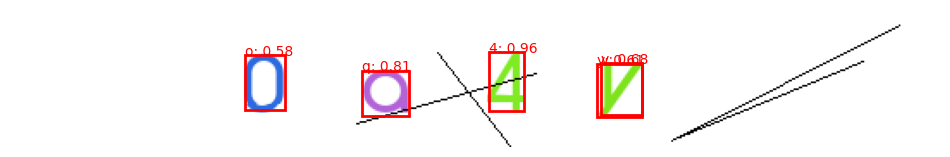

In [ ]:
# Load trained model
model_path = "outputs/model_epoch_2.pth"
model = get_model(num_classes)
model.load_state_dict(torch.load(model_path))
model.to(device)

# Test the model
model.eval()

def prepare_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image_tensor = F.to_tensor(image).unsqueeze(0)
    return image_tensor.to(device)

# Load category mapping from the annotations file
import json
with open('output/split_data/train/annotations.json', 'r') as f:
    coco_data = json.load(f)
    
# Create category mapping: category_id -> name
COCO_CLASSES = {cat['id']: cat['name'] for cat in coco_data['categories']}

def get_class_name(class_id):
    return COCO_CLASSES.get(class_id, f"unknown_{class_id}")

def draw_boxes(image, prediction, fig_size=(10, 10)):
    boxes = prediction[0]["boxes"].cpu().numpy()
    labels = prediction[0]["labels"].cpu().numpy()
    scores = prediction[0]["scores"].cpu().numpy()

    threshold = 0.5 # threshold for showing boxes, (e.g. score > 0.5)

    plt.figure(figsize=fig_size)

    for box, label, score in zip(boxes, labels, scores):
        if score > threshold:
            x_min, y_min, x_max, y_max = box
            class_name = get_class_name(label)
            plt.imshow(image)
            plt.gca().add_patch(plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, fill=False, edgecolor="red", linewidth=2, facecolor="none"))
            plt.text(x_min, y_min, f"{class_name}: {score:.2f}", color="red")

    
    plt.axis("off")
    plt.show()

for image in os.listdir("/Users/wesho/repos/captcha-model/rcnn/output/split_data/test"):
    image_path = f"/Users/wesho/repos/captcha-model/rcnn/output/split_data/test/{image}"
    image_tensor = prepare_image(image_path)

    with torch.no_grad():
        prediction = model(image_tensor)
    draw_boxes(Image.open(image_path), prediction, fig_size=(12, 10))
